# 01. EDA — ESS 배터리 수명 예측

- 데이터: MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019)
- 목표: Batch 1 / 2 / 3의 특성을 비교하고, 그 결과를 근거로 모델 설계 전략을 세운다.

## 0. 환경 설정

**목적**: 분석에 쓰는 라이브러리, 경로, 그래프 설정, 난수 시드를 한곳에 모아 재현 가능하게 한다.

In [9]:
import os
import logging
import warnings

import numpy as np
import pandas as pd
import mat73
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 경고 및 mat73의 string 타입 로딩 메시지 숨김
warnings.filterwarnings('ignore')
logging.getLogger().setLevel(logging.CRITICAL)

# 재현성
SEED = 42
np.random.seed(SEED)

# 경로
DATA_DIR = '../data'
PROC_DIR = '../data/processed'
FIG_DIR = '../results/figures'
os.makedirs(PROC_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

# 그래프 설정 (한글 폰트 포함)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# 표 출력 설정
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

## 1. 데이터 준비

**목적**: 세 배치의 사이클별 요약(`summary`)을 하나의 DataFrame으로 모은다.
원본 파일은 배치당 2~3GB라 매번 읽기 어려우므로, 추출 결과를 파일로 저장해 이후에는 그 파일만 사용한다.

In [10]:
def load_mat(path):
    """.mat 파일 로더. v7.3(HDF5)은 mat73, 그 이하는 scipy로 읽는다."""
    try:
        data = mat73.loadmat(path)
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
    return data


def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환한다."""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d


def extract_summary(batch, batch_no):
    """배치 내 모든 셀의 summary를 사이클 단위 DataFrame으로 변환한다."""
    records = []
    for i, cell in enumerate(batch):
        s = cell['summary']
        qd = np.array(s['QDischarge'])
        qc = np.array(s['QCharge'])
        ir = np.array(s['IR'])
        tmax = np.array(s['Tmax'])
        tavg = np.array(s['Tavg'])
        tmin = np.array(s['Tmin'])
        ct = np.array(s['chargetime'])

        cycle_life = float(cell['cycle_life'])
        policy = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')

        for c in range(len(qd)):
            records.append({
                'batch': batch_no,
                'cell_id': f'b{batch_no}c{i}',
                'cycle': c + 1,
                'cycle_life': cycle_life,
                'charging_policy': policy,
                'QD': qd[c],
                'QC': qc[c],
                'IR': ir[c],
                'Tmax': tmax[c],
                'Tavg': tavg[c],
                'Tmin': tmin[c],
                'chargetime': ct[c],
            })
    return pd.DataFrame(records)

In [11]:
FILES = {
    1: '2017-05-12_batchdata_updated_struct_errorcorrect.mat',
    2: '2018-02-20_batchdata_updated_struct_errorcorrect.mat',
    3: '2018-04-12_batchdata_updated_struct_errorcorrect.mat',
}

dfs = []
for b, fname in FILES.items():
    print(f'Batch {b} 로딩 중...')
    mat = load_mat(os.path.join(DATA_DIR, fname))
    batch = to_list_of_dicts(mat['batch'])
    dfs.append(extract_summary(batch, b))
    del mat, batch

df = pd.concat(dfs, ignore_index=True)
df.to_parquet(os.path.join(PROC_DIR, 'summary.parquet'))

print(df.shape)
print(df.groupby('batch')['cell_id'].nunique())

Batch 1 로딩 중...
Batch 2 로딩 중...
Batch 3 로딩 중...
(116722, 12)
batch
1    46
2    47
3    46
Name: cell_id, dtype: int64


**결과 해석**
- 세 배치를 합친 summary는 116,722행(사이클 단위), 12열이다.
- 셀 수는 Batch 1 46개, Batch 2 47개, Batch 3 46개로 총 139개다.
- 추출 결과를 `data/processed/summary.parquet`으로 저장했다. 이후 분석은 이 파일에서 시작한다.

In [12]:
df = pd.read_parquet(os.path.join(PROC_DIR, 'summary.parquet'))
df.head()

,batch,cell_id,cycle,cycle_life,charging_policy,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
0,1,b1c0,1,1190.0,3.6C(80%)-3.6C,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,1,b1c0,2,1190.0,3.6C(80%)-3.6C,1.070689,1.071042,0.016742,35.652016,31.875011,29.566130,13.341250
2,1,b1c0,3,1190.0,3.6C(80%)-3.6C,1.071900,1.071674,0.016724,35.692978,31.931490,29.604385,13.425777
3,1,b1c0,4,1190.0,3.6C(80%)-3.6C,1.072510,1.072304,0.016681,35.680588,31.932603,29.744202,13.425167
4,1,b1c0,5,1190.0,3.6C(80%)-3.6C,1.073174,1.072970,0.016662,35.728691,31.959322,29.644709,13.341442


## 2. Q1 — Cycle Life 분포는 어떻게 생겼는가?

**목적**: 학습 배치(Batch 1)와 테스트 배치(Batch 2, 3)의 수명 분포를 비교한다.
- 분포의 범위와 형태는 배치마다 같은가
- 장수명(>1,000) / 단수명(<500) 셀의 비율은 어떤가
- 유독 짧거나 값이 이상한 셀이 있는가

In [13]:
cells = df.drop_duplicates('cell_id')[['batch', 'cell_id', 'cycle_life', 'charging_policy']].reset_index(drop=True)

print('수명 값이 없는 셀 수')
print(cells[cells['cycle_life'].isna()].groupby('batch').size())

cells.groupby('batch')['cycle_life'].describe().round(1)

수명 값이 없는 셀 수
batch
2    8
3    2
dtype: int64


,count,mean,std,min,25%,50%,75%,max
batch,,,,,,,,
1,46.0,844.7,184.6,534.0,703.2,858.5,914.2,1227.0
2,39.0,565.7,222.2,392.0,439.5,472.0,508.5,1186.0
3,44.0,1059.7,313.9,541.0,828.0,1005.5,1155.2,1935.0


**결과 해석 — 기술통계**

- **수명 값이 없는 셀이 있다.** Batch 2에서 8개, Batch 3에서 2개. 어떤 셀인지는 아래에서 확인한다.
- **세 배치의 수명 수준이 다르다.** 중앙값이 Batch 1 858.5, Batch 2 472, Batch 3 1,005.5다.
- **Batch 2는 한쪽으로 치우친 분포다.** 75% 지점이 508.5인데 최댓값은 1,186이고, 평균(565.7)이 중앙값(472)보다 크다. 대부분의 셀이 400~500대에 몰려 있고 일부만 멀리 떨어져 있다.
- **Batch 2의 대부분은 Batch 1의 범위 밖이다.** Batch 1의 최솟값은 534인데, Batch 2는 75% 지점이 508.5다. Batch 2 셀의 4분의 3 이상이 Batch 1에서 가장 짧은 셀보다 수명이 짧다.

**시사점**: Batch 1로 학습해 Batch 2를 평가하면, 모델은 학습 때 본 적 없는 짧은 수명 구간을 예측해야 한다.

In [14]:
cells[cells['cycle_life'].isna()]

,batch,cell_id,cycle_life,charging_policy
68,2,b2c22,NaN,VarCharge-2C-100cycles
69,2,b2c23,NaN,VarCharge-4C-100cycles
81,2,b2c35,NaN,VarCharge-6C-100cycles
82,2,b2c36,NaN,VarCharge-8C-100cycles
83,2,b2c37,NaN,3.6C(80%)-3.6C(SLOWCYCLE
84,2,b2c38,NaN,4.8C(80%)-4.8C(SLOWCYCLE
85,2,b2c39,NaN,3.6C(9%)-5C(SLOWCYCLE
86,2,b2c40,NaN,5.2C(58%)-4C(SLOWCYCLE
116,3,b3c23,NaN,4.8C(80%)-4.8C-newstructure
125,3,b3c32,NaN,4.8C(80%)-4.8C-newstructure


**결과 해석 — 수명 값이 없는 셀**

- **Batch 2의 8셀은 이름부터 다른 실험이다.** 충전 정책이 `VarCharge-...` (4셀)과 `...(SLOWCYCLE` (4셀)로 표기되어 있다. 다른 셀들의 정책 표기(`C1(Q1%)-C2`)와 형식이 다르다.
- **Batch 3의 2셀은 정책 표기가 정상이다.** 둘 다 `4.8C(80%)-4.8C-newstructure`로, 수명 값만 비어 있다. 왜 비어 있는지는 이 표만으로는 알 수 없다.

**결정**: 수명 값이 없는 10셀은 타깃이 없어 수명 예측의 학습·평가에 쓸 수 없으므로 분석 대상에서 제외한다.
Batch 3의 2셀이 왜 비어 있는지는 열화 곡선(Q2)에서 확인한다.

In [17]:
cells['newstructure'] = cells['charging_policy'].str.contains('newstructure')
cells.groupby(['batch', 'newstructure']).size()

batch  newstructure
1      False           46
2      False           38
       True             9
3      True            46
dtype: int64

**결과 해석 — `newstructure` 표기**

- Batch 1은 전부 표기가 없고, Batch 3은 전부 `newstructure`다.
- **Batch 2에는 두 부류가 섞여 있다**: 표기 없는 38셀과 `newstructure` 9셀.
- 이 표기가 무엇을 의미하는지는 데이터에 설명이 없다. 다만 Batch 2의 9셀이 Batch 3과 같은 표기를 공유하므로, Batch 2를 하나의 균일한 집단으로 보기 전에 두 부류의 수명이 같은지 확인할 필요가 있다.

In [18]:
cells.dropna(subset=['cycle_life']).groupby(['batch', 'newstructure'])['cycle_life'].describe().round(1)

count    mean    std    min    25%     50%     75%     max
batch newstructure                                                            
1     False          46.0   844.7  184.6  534.0  703.2   858.5   914.2  1227.0
2     False          30.0   453.0   34.8  392.0  425.2   451.0   476.2   514.0
      True            9.0   941.6  153.6  777.0  809.0   904.0  1029.0  1186.0
3     True           44.0  1059.7  313.9  541.0  828.0  1005.5  1155.2  1935.0

**결과 해석 — Batch 2 안의 두 집단**

- **Batch 2의 두 부류는 수명 범위가 겹치지 않는다.** 표기 없는 30셀은 392~514, `newstructure` 9셀은 777~1,186이다.
- **표기 없는 30셀은 수명이 매우 균일하다.** 표준편차가 34.8로, Batch 1(184.6)이나 Batch 3(313.9)보다 훨씬 작다.
- **`newstructure` 9셀은 Batch 3과 수준이 비슷하다.** 중앙값이 904로 Batch 3(1,005.5)에 가깝고, Batch 2의 나머지 셀(451)과는 2배 차이가 난다.
- Batch 2 전체 통계에서 평균(565.7)이 중앙값(472)보다 컸던 것은 한쪽으로 치우친 분포여서가 아니라, **성격이 다른 두 집단이 섞여 있었기 때문**이다.

**시사점**
- Batch 2를 하나의 집단으로 평가하면 두 집단의 결과가 섞여 해석이 어렵다. 테스트 성능은 Batch 2 전체와 함께 **두 집단으로 나눠서** 본다.
- Batch 1의 최소 수명은 534인데, Batch 2의 표기 없는 30셀은 최대가 514다. 이 30셀은 **전부 Batch 1의 수명 범위 밖**에 있다.

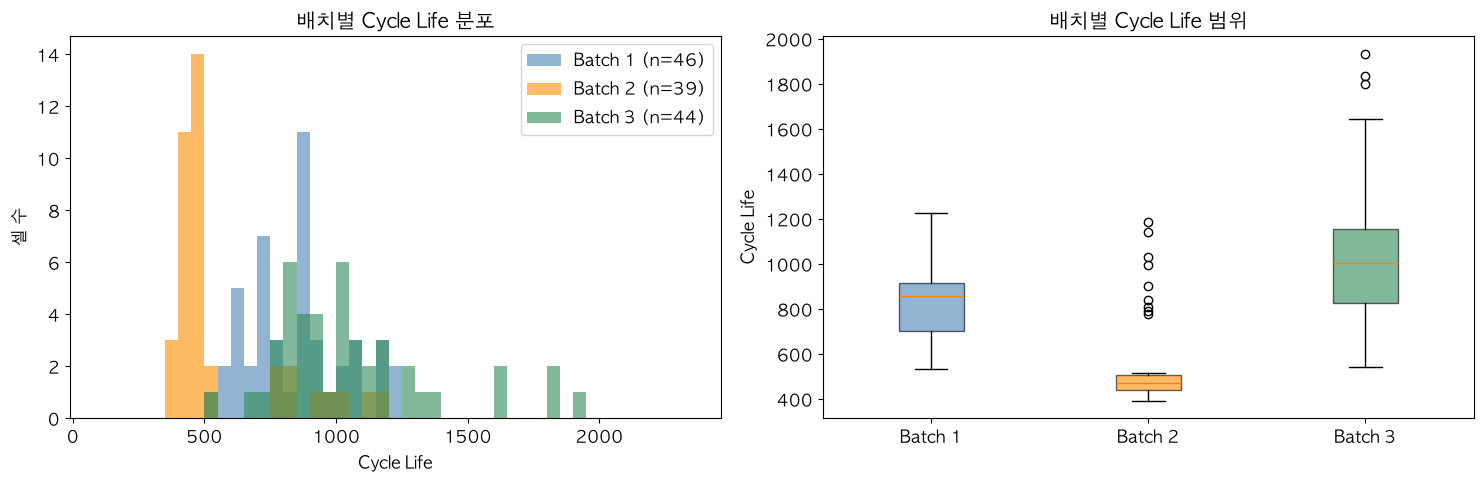

In [15]:
colors = {1: 'steelblue', 2: 'darkorange', 3: 'seagreen'}
bins = np.arange(100, 2400, 50)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for b in [1, 2, 3]:
    life = cells.loc[cells['batch'] == b, 'cycle_life'].dropna()
    axes[0].hist(life, bins=bins, alpha=0.6, color=colors[b], label=f'Batch {b} (n={len(life)})')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('셀 수')
axes[0].set_title('배치별 Cycle Life 분포')
axes[0].legend()

data = [cells.loc[cells['batch'] == b, 'cycle_life'].dropna() for b in [1, 2, 3]]
bp = axes[1].boxplot(data, tick_labels=['Batch 1', 'Batch 2', 'Batch 3'], patch_artist=True)
for patch, b in zip(bp['boxes'], [1, 2, 3]):
    patch.set(facecolor=colors[b], alpha=0.6)
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('배치별 Cycle Life 범위')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'q1_cycle_life.png'), dpi=150)
plt.show()

**결과 해석 — 분포 그래프**

- **Batch 1과 Batch 2는 거의 겹치지 않는다.** Batch 2의 대부분은 350~550 구간에 몰려 있고, Batch 1은 그 오른쪽인 534부터 시작한다.
- **박스플롯이 Batch 2의 이상치로 표시한 9개 점은 이상치가 아니다.** 앞에서 확인한 `newstructure` 9셀(777~1,186)과 일치한다. 값이 튀는 개별 셀이 아니라 성격이 다른 집단이다.
- **Batch 3은 범위가 가장 넓다.** 541~1,935에 걸쳐 있고, 1,600 이상인 셀이 일부 있어 오른쪽 꼬리가 길다.
- 세 배치 모두 Batch 1과 겹치는 구간(약 550~1,200)에 셀이 있지만, 그 밖의 구간은 Batch 2(짧은 쪽)와 Batch 3(긴 쪽)에만 있다.

**시사점**: 학습 배치의 수명 범위(534~1,227)보다 테스트 배치의 범위가 양쪽으로 더 넓다. Batch 2는 짧은 쪽으로, Batch 3은 긴 쪽으로 학습 범위를 벗어난다.

In [19]:
ratio = cells.dropna(subset=['cycle_life']).groupby('batch')['cycle_life'].agg(
    셀수='size',
    단수명_500미만=lambda x: (x < 500).sum(),
    장수명_1000초과=lambda x: (x > 1000).sum(),
    분류기준_550미만=lambda x: (x < 550).sum(),
)
ratio

,셀수,단수명_500미만,장수명_1000초과,분류기준_550미만
batch,,,,
1,46,0,10,1
2,39,28,3,30
3,44,0,23,1


**결과 해석 — 장수명/단수명 비율**

- **단수명(<500) 셀은 Batch 2에만 있다.** Batch 2는 39셀 중 28셀이 단수명이고, Batch 1과 Batch 3에는 한 개도 없다.
- **장수명(>1,000) 셀은 Batch 3에 가장 많다.** Batch 3은 44셀 중 23셀, Batch 1은 46셀 중 10셀, Batch 2는 39셀 중 3셀이다.
- **분류 기준(550사이클)으로 나누면 Batch 1에는 단수명 클래스가 1개뿐이다.** 46셀 중 45셀이 장수명 클래스다. 반면 Batch 2는 39셀 중 30셀이 단수명 클래스다.

**시사점**: Batch 1로 분류 모델을 학습하면 단수명 클래스의 표본이 1개라 그 클래스의 특징을 배울 수 없다. 그런데 테스트 배치(Batch 2)는 대부분이 단수명 클래스다. 과제 조건(Batch 1 학습 → Batch 2 평가)에서는 **Classification이 성립하지 않는다.**

### Q1 결론

**확인한 사실**
1. 수명 값이 없는 셀이 10개 있다. Batch 2의 8셀은 다른 실험(`VarCharge`, `SLOWCYCLE`)이고, Batch 3의 2셀은 원인 미확인이다.
2. 세 배치의 수명 분포가 다르다. 중앙값이 Batch 1 858.5, Batch 2 472, Batch 3 1,005.5다.
3. Batch 2는 두 집단의 혼합이다. 표기 없는 30셀(392~514)과 `newstructure` 9셀(777~1,186)의 수명 범위가 겹치지 않는다.
4. Batch 2의 표기 없는 30셀은 전부 Batch 1의 최소 수명(534)보다 짧다.
5. 분류 기준 550사이클 미만인 셀이 Batch 1에는 1개뿐이다.

**모델 설계에 주는 시사점**
- **Regression을 선택한다.** Batch 1에는 단수명 클래스가 1개뿐이라 분류 모델을 학습할 수 없다. (사실 5)
- **학습 범위 밖을 예측해야 하는 문제다.** 테스트 셀의 다수가 학습 배치의 수명 범위 밖에 있으므로, 모델을 고를 때 학습 범위 밖에서도 예측이 가능한지를 기준에 넣는다. (사실 2, 4)
- **테스트 성능은 Batch 2의 두 집단을 나눠서 본다.** (사실 3)

**남은 질문**
- Batch 3의 2셀은 왜 수명 값이 없는가 → Q2에서 열화 곡선으로 확인
- Batch 1의 `cycle_life` 46개는 모두 실제 EOL 도달 시점인가 → Q2에서 확인
- `newstructure`는 무엇을 의미하며, Batch 2의 두 집단은 왜 수명이 다른가